# Understanding Vectorization and Its Performance Benefits

This notebook explores the performance benefits of using vectorized operations in Python, particularly with NumPy, compared to traditional loop-based implementations. Vectorization is a key optimization technique for machine learning workflows that can dramatically improve performance.

## Learning Objectives

- Understand what vectorization is and why it's important
- Compare loop-based versus vectorized implementations
- Measure and visualize performance differences
- Learn when and how to apply vectorization in real ML scenarios

In [2]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
import pandas as pd
from IPython.display import display

# Add parent directory to path to import our module
sys.path.append('..')
from phase0.python_optimization.vectorization import time_function, vector_sum_loops, vector_sum_numpy
from phase0.python_optimization.profiling import benchmark_loop_vs_vectorized

## 1. What is Vectorization?

Vectorization is the process of converting operations that act on individual elements to operations that act on arrays or vectors. This allows:

- Efficient use of modern CPU architectures via SIMD (Single Instruction, Multiple Data) operations
- Reduction in Python interpreter overhead
- Potential use of optimized C/C++ implementations behind the scenes
- More readable and concise code

Let's start with a simple example comparing traditional loops with NumPy's vectorized operations.

In [3]:
# Create some test data
n_vectors = 10000
n_dims = 100
vectors = np.random.rand(n_vectors, n_dims).tolist()

# Compare loop-based and NumPy implementations
result_loops, time_loops = time_function(vector_sum_loops, vectors)
result_numpy, time_numpy = time_function(vector_sum_numpy, vectors)

# Verify that results are the same (within floating point precision)
np.allclose(result_loops, result_numpy)

True

,Implementation,Time (seconds),Relative Speed
0,Loops,0.031852,1x
1,NumPy Vectorized,0.027405,1.2x


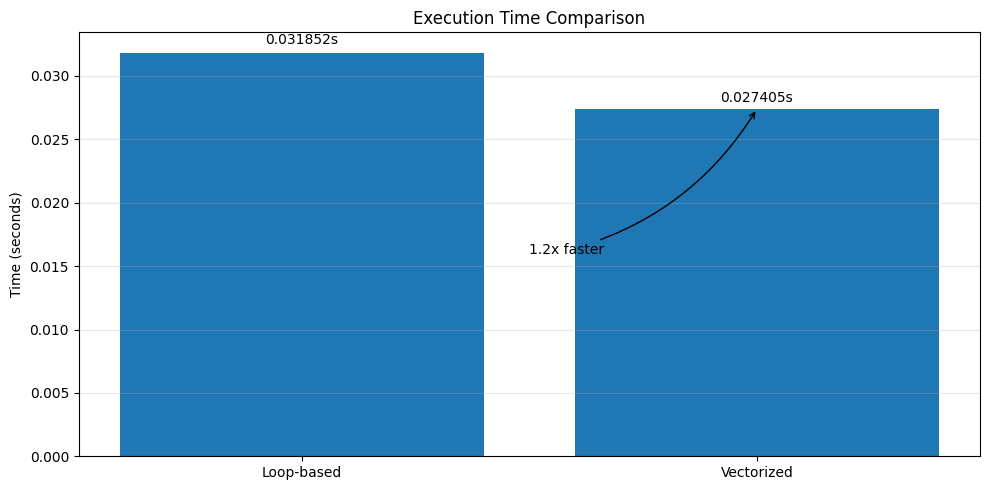

In [4]:
# Compare execution times
speedup = time_loops / time_numpy

# Create a comparison table
comparison = pd.DataFrame({
    'Implementation': ['Loops', 'NumPy Vectorized'],
    'Time (seconds)': [time_loops, time_numpy],
    'Relative Speed': ['1x', f'{speedup:.1f}x']
})

display(comparison)

# Plot the comparison
plt.figure(figsize=(10, 5))
plt.bar(['Loop-based', 'Vectorized'], [time_loops, time_numpy])
plt.title('Execution Time Comparison')
plt.ylabel('Time (seconds)')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)

# Add text labels on top of bars
plt.text(0, time_loops*1.02, f'{time_loops:.6f}s', ha='center')
plt.text(1, time_numpy*1.02, f'{time_numpy:.6f}s', ha='center')

# Add speedup annotation
plt.annotate(f'{speedup:.1f}x faster', 
             xy=(1, time_numpy), 
             xytext=(0.5, time_loops/2),
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2"))

plt.tight_layout()
plt.show()

## 2. Why Vectorization Works: Behind the Scenes

Let's understand why vectorized operations are faster:

1. **Interpreter Overhead**: Python is an interpreted language where each loop iteration incurs overhead
2. **SIMD Operations**: NumPy utilizes CPU hardware that can process multiple data points simultaneously
3. **Optimized Implementations**: NumPy functions are implemented in C/C++ and highly optimized
4. **Memory Access Patterns**: Vectorized operations can optimize memory access, improving cache performance

Let's examine how performance scales with data size:

,Data Size,Loop Time (s),NumPy Time (s),Speedup Factor
0,100,0.000170,0.000196,0.867558
1,1000,0.002189,0.002264,0.966832
2,10000,0.017693,0.016548,1.069185
3,100000,0.165392,0.138024,1.198283


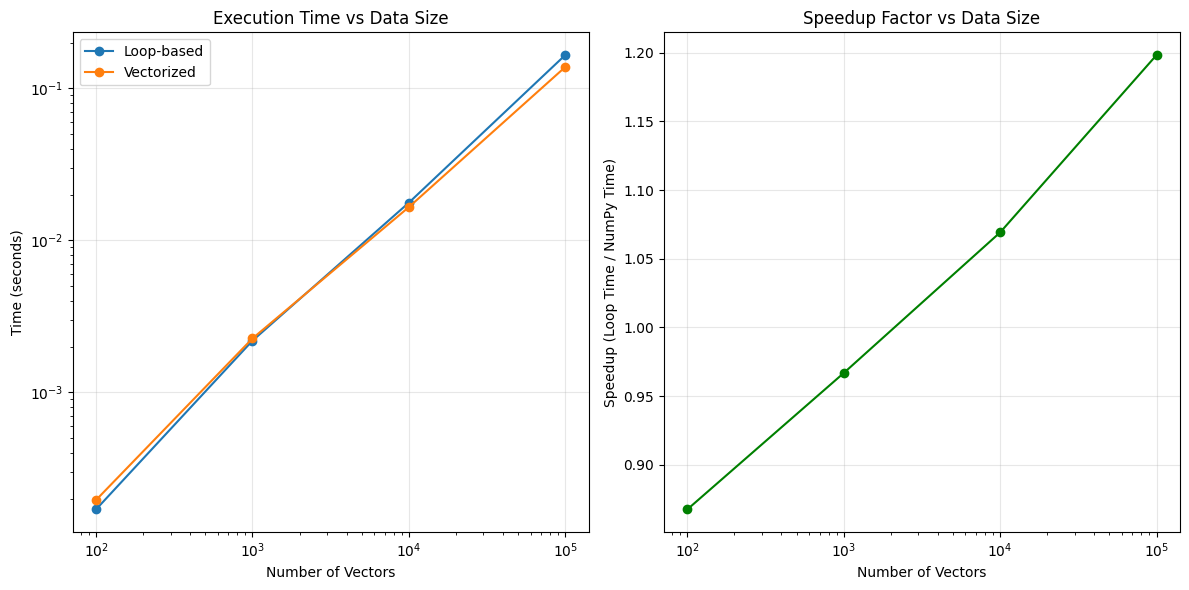

In [5]:
# Test different data sizes
sizes = [100, 1000, 10000, 100000]
loop_times = []
numpy_times = []
speedups = []

for size in sizes:
    test_vectors = np.random.rand(size, 50).tolist()
    
    # Time the loop-based implementation
    _, loop_time = time_function(vector_sum_loops, test_vectors)
    loop_times.append(loop_time)
    
    # Time the NumPy implementation
    _, numpy_time = time_function(vector_sum_numpy, test_vectors)
    numpy_times.append(numpy_time)
    
    # Calculate speedup
    speedups.append(loop_time / numpy_time)

# Create a DataFrame for the results
scaling_results = pd.DataFrame({
    'Data Size': sizes,
    'Loop Time (s)': loop_times,
    'NumPy Time (s)': numpy_times,
    'Speedup Factor': speedups
})

display(scaling_results)

# Plot the scaling comparison
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(sizes, loop_times, 'o-', label='Loop-based')
plt.plot(sizes, numpy_times, 'o-', label='Vectorized')
plt.title('Execution Time vs Data Size')
plt.xlabel('Number of Vectors')
plt.ylabel('Time (seconds)')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(sizes, speedups, 'o-', color='green')
plt.title('Speedup Factor vs Data Size')
plt.xlabel('Number of Vectors')
plt.ylabel('Speedup (Loop Time / NumPy Time)')
plt.xscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Common Vectorized Operations

Let's explore some common operations that benefit from vectorization in machine learning workflows:

,Operation,Loop Time (s),Vectorized Time (s),Speedup Factor
0,addition,0.158276,0.001650,95.933092
1,multiplication,0.172864,0.000929,186.052348
2,sum,0.087427,0.000392,223.185636


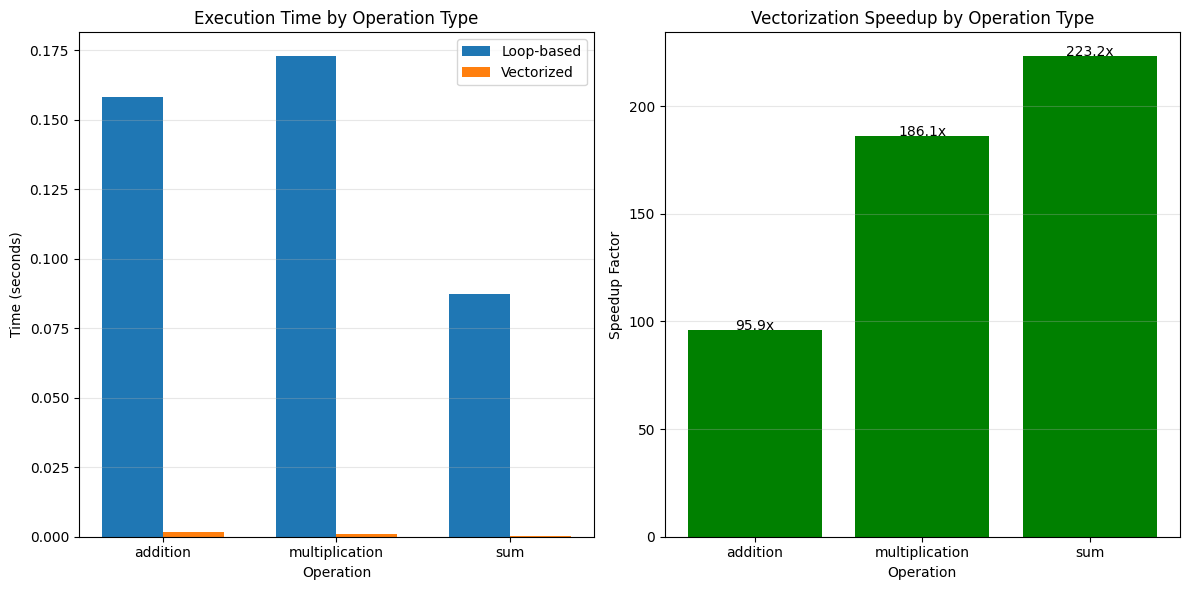

In [6]:
# Run the benchmark from our profiling module
benchmark_results = benchmark_loop_vs_vectorized(size=1000000)

# Create a summary table
operations = list(benchmark_results.keys())
loop_times = [benchmark_results[op]['loop_time'] for op in operations]
vectorized_times = [benchmark_results[op]['vectorized_time'] for op in operations]
speedup_factors = [benchmark_results[op]['speedup'] for op in operations]

benchmark_df = pd.DataFrame({
    'Operation': operations,
    'Loop Time (s)': loop_times,
    'Vectorized Time (s)': vectorized_times,
    'Speedup Factor': speedup_factors
})

display(benchmark_df)

# Plot the results
plt.figure(figsize=(12, 6))

# Bar chart of execution times
plt.subplot(1, 2, 1)
bar_width = 0.35
index = np.arange(len(operations))

plt.bar(index, loop_times, bar_width, label='Loop-based')
plt.bar(index + bar_width, vectorized_times, bar_width, label='Vectorized')

plt.xlabel('Operation')
plt.ylabel('Time (seconds)')
plt.title('Execution Time by Operation Type')
plt.xticks(index + bar_width/2, operations)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Bar chart of speedup factors
plt.subplot(1, 2, 2)
plt.bar(operations, speedup_factors, color='green')
plt.xlabel('Operation')
plt.ylabel('Speedup Factor')
plt.title('Vectorization Speedup by Operation Type')
plt.grid(axis='y', alpha=0.3)

# Add text labels on top of bars
for i, v in enumerate(speedup_factors):
    plt.text(i, v + 0.1, f'{v:.1f}x', ha='center')

plt.tight_layout()
plt.show()

## 4. Implementing a Simple Machine Learning Algorithm: Linear Regression

Let's implement linear regression both with loops and with vectorized operations to see the performance difference in a realistic scenario:

In [7]:
# Generate synthetic data for linear regression
np.random.seed(42)  # For reproducibility
num_samples = 10000
num_features = 10

# True parameters: w (weights) and b (bias)
true_w = np.random.randn(num_features)
true_b = 5

# Generate features X and target y with some noise
X = np.random.randn(num_samples, num_features)
y = X @ true_w + true_b + np.random.randn(num_samples) * 0.5  # Add noise

# Convert to Python lists for loop implementation
X_list = X.tolist()
y_list = y.tolist()

In [8]:
def linear_regression_loop(X, y, learning_rate=0.01, num_iterations=1000):
    """Linear regression with gradient descent using loops."""
    n_samples = len(X)
    n_features = len(X[0])
    
    # Initialize weights and bias
    w = [0.0] * n_features
    b = 0.0
    
    # Training history
    loss_history = []
    
    for iteration in range(num_iterations):
        # Compute predictions
        predictions = []
        for i in range(n_samples):
            pred = b
            for j in range(n_features):
                pred += w[j] * X[i][j]
            predictions.append(pred)
        
        # Compute loss (MSE)
        loss = 0.0
        for i in range(n_samples):
            loss += (predictions[i] - y[i])**2
        loss /= n_samples
        loss_history.append(loss)
        
        # Compute gradients
        dw = [0.0] * n_features
        db = 0.0
        
        for i in range(n_samples):
            error = predictions[i] - y[i]
            db += error
            for j in range(n_features):
                dw[j] += error * X[i][j]
        
        # Normalize gradients
        db /= n_samples
        for j in range(n_features):
            dw[j] /= n_samples
        
        # Update parameters
        b -= learning_rate * db
        for j in range(n_features):
            w[j] -= learning_rate * dw[j]
            
    return w, b, loss_history

def linear_regression_vectorized(X, y, learning_rate=0.01, num_iterations=1000):
    """Linear regression with gradient descent using vectorized operations."""
    n_samples, n_features = X.shape
    
    # Initialize weights and bias
    w = np.zeros(n_features)
    b = 0.0
    
    # Training history
    loss_history = []
    
    for iteration in range(num_iterations):
        # Compute predictions (vectorized)
        predictions = X @ w + b
        
        # Compute loss (MSE, vectorized)
        loss = np.mean((predictions - y)**2)
        loss_history.append(loss)
        
        # Compute gradients (vectorized)
        error = predictions - y
        dw = (X.T @ error) / n_samples
        db = np.mean(error)
        
        # Update parameters
        w -= learning_rate * dw
        b -= learning_rate * db
            
    return w, b, loss_history

,Implementation,Time (seconds),Final Loss,Relative Speed
0,Loop-based,1.039666,4.606698,1x
1,Vectorized,0.007929,4.606698,131.1x


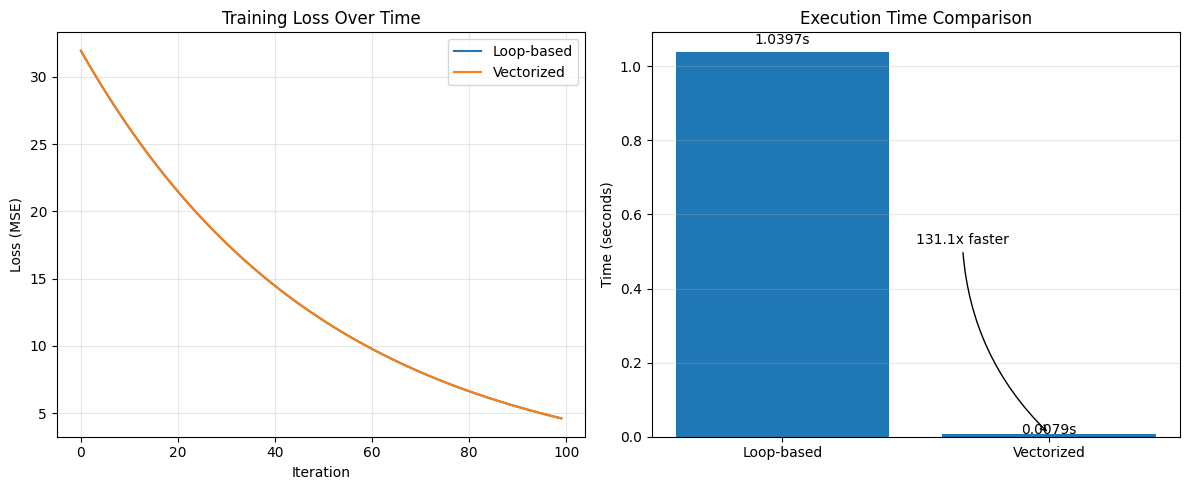

In [9]:
# Time the loop implementation
(w_loop, b_loop, loss_history_loop), time_loop = time_function(
    linear_regression_loop, X_list, y_list, 0.01, 100)

# Time the vectorized implementation
(w_vec, b_vec, loss_history_vec), time_vec = time_function(
    linear_regression_vectorized, X, y, 0.01, 100)

# Calculate speedup
lr_speedup = time_loop / time_vec

# Display results
lr_comparison = pd.DataFrame({
    'Implementation': ['Loop-based', 'Vectorized'],
    'Time (seconds)': [time_loop, time_vec],
    'Final Loss': [loss_history_loop[-1], loss_history_vec[-1]],
    'Relative Speed': ['1x', f'{lr_speedup:.1f}x']
})

display(lr_comparison)

# Plot loss history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_history_loop, label='Loop-based')
plt.plot(loss_history_vec, label='Vectorized')
plt.xlabel('Iteration')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss Over Time')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.bar(['Loop-based', 'Vectorized'], [time_loop, time_vec])
plt.title('Execution Time Comparison')
plt.ylabel('Time (seconds)')
plt.grid(axis='y', alpha=0.3)

# Add text labels on top of bars
plt.text(0, time_loop*1.02, f'{time_loop:.4f}s', ha='center')
plt.text(1, time_vec*1.02, f'{time_vec:.4f}s', ha='center')

# Add speedup annotation
plt.annotate(f'{lr_speedup:.1f}x faster', 
             xy=(1, time_vec), 
             xytext=(0.5, time_loop/2),
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2"))

plt.tight_layout()
plt.show()

## 5. Memory Efficiency Considerations

While vectorization dramatically improves performance, it can sometimes use more memory. Let's examine memory usage:

In [10]:
import sys

# Create test data
n = 1000000
data = list(range(n))
data_np = np.array(data)

# Memory usage
memory_list = sys.getsizeof(data) + sum(sys.getsizeof(i) for i in data[:1000]) * (n / 1000)
memory_np = sys.getsizeof(data_np) + data_np.nbytes

print(f"Estimated Python list memory: {memory_list / (1024*1024):.2f} MB")
print(f"NumPy array memory: {memory_np / (1024*1024):.2f} MB")

# Memory comparison for operations
print("\nMemory for operations:")

# Loop implementation (creating new list)
def add_one_loop(data):
    result = []
    for x in data:
        result.append(x + 1)
    return result

# In-place loop implementation
def add_one_loop_inplace(data):
    for i in range(len(data)):
        data[i] += 1
    return data

# Vectorized implementation
def add_one_vectorized(data):
    return data + 1

# Copy data to avoid modifying originals
data_copy = data.copy()
data_np_copy = data_np.copy()

# Measure memory usage for loop implementation with new list
result_loop = add_one_loop(data_copy[:1000])  # Just use a sample to estimate
memory_result_loop = sys.getsizeof(result_loop) + sum(sys.getsizeof(i) for i in result_loop) * (n / 1000)
print(f"New list from loop operation (estimated): {memory_result_loop / (1024*1024):.2f} MB")

# Measure memory usage for in-place loop implementation
add_one_loop_inplace(data_copy)  # Modifies in place
memory_inplace = sys.getsizeof(data_copy) + sum(sys.getsizeof(i) for i in data_copy[:1000]) * (n / 1000)
print(f"In-place loop operation (estimated): {memory_inplace / (1024*1024):.2f} MB")

# Measure memory usage for vectorized implementation
result_np = add_one_vectorized(data_np_copy)
memory_result_np = sys.getsizeof(result_np) + result_np.nbytes
print(f"NumPy vectorized operation result: {memory_result_np / (1024*1024):.2f} MB")

Estimated Python list memory: 34.33 MB
NumPy array memory: 15.26 MB

Memory for operations:
New list from loop operation (estimated): 26.71 MB
In-place loop operation (estimated): 34.33 MB
NumPy vectorized operation result: 15.26 MB


## 6. Vectorization Best Practices and Tips

Here are some key tips for effective vectorization in Python and NumPy:

1. **Use NumPy's Universal Functions (ufuncs)**: Operations like `np.add`, `np.multiply`, etc. are highly optimized
2. **Avoid Explicit Loops**: Convert loops to vectorized operations when possible
3. **Preallocate Arrays**: Use `np.empty`, `np.zeros`, or `np.ones` instead of growing arrays
4. **Use Broadcasting**: Leverage NumPy's broadcasting for operations between arrays of different shapes
5. **Utilize Specialized Functions**: Use specialized functions like `np.dot`, `np.matmul`, etc. for matrix operations
6. **Profile Your Code**: Use profiling tools to identify bottlenecks
7. **Consider Memory Usage**: Vectorized operations can sometimes use more memory

Let's implement an example that demonstrates these principles:

In [11]:
# Example: Computing distances between points

def distance_matrix_loops(points):
    """Compute distance matrix between all pairs of points using loops."""
    n = len(points)
    distances = [[0] * n for _ in range(n)]
    
    for i in range(n):
        for j in range(n):
            # Compute Euclidean distance
            dist = 0
            for k in range(len(points[i])):
                dist += (points[i][k] - points[j][k]) ** 2
            distances[i][j] = dist ** 0.5
    
    return distances

def distance_matrix_vectorized(points):
    """Compute distance matrix between all pairs of points using vectorization."""
    # Convert to numpy array if not already
    points = np.asarray(points)
    
    # Precompute squared norms of each point
    sq_norms = np.sum(points**2, axis=1)
    
    # Use broadcasting to compute distances efficiently
    # ||a - b||^2 = ||a||^2 + ||b||^2 - 2<a,b>
    sq_distances = sq_norms[:, None] + sq_norms[None, :] - 2 * np.dot(points, points.T)
    
    # Handle numerical imprecision (avoid negative values due to floating point errors)
    sq_distances = np.maximum(sq_distances, 0)
    
    # Return the square root of the squared distances
    return np.sqrt(sq_distances)

# Generate some random points
n_points = 1000
n_dims = 50
points = np.random.rand(n_points, n_dims)
points_list = points.tolist()

# Compare performance
print("Computing distance matrix...")
_, loop_time = time_function(distance_matrix_loops, points_list)
_, vec_time = time_function(distance_matrix_vectorized, points)

speedup = loop_time / vec_time
print(f"Loop implementation: {loop_time:.4f} seconds")
print(f"Vectorized implementation: {vec_time:.4f} seconds")
print(f"Speedup: {speedup:.1f}x")

Computing distance matrix...
Loop implementation: 3.8069 seconds
Vectorized implementation: 0.0134 seconds
Speedup: 284.5x


## 7. Conclusion and Practical Takeaways

In this notebook, we've explored the performance benefits of vectorization in Python, particularly for machine learning applications.

### Key Takeaways:

1. **Significant Performance Gains**: Vectorized operations can be orders of magnitude faster than loop-based implementations
2. **Scalability with Data Size**: The performance gap typically widens as data size increases
3. **Readability and Conciseness**: Vectorized code is often more concise and expressive
4. **Memory Considerations**: While vectorization improves performance, it may use more memory in some cases
5. **Critical for ML Workflows**: Vectorization is essential for efficient machine learning implementations

### When to Use Vectorization:

- **Data Preprocessing**: Feature scaling, normalization, encoding
- **Model Training**: Computing predictions, gradients, and loss functions
- **Numerical Operations**: Matrix multiplications, transformations
- **Batch Processing**: Processing multiple samples at once

### When Loops Might Still Be Appropriate:

- Complex algorithms that don't map well to vector operations
- When memory usage is a critical constraint
- For small datasets where the overhead of creating NumPy arrays might outweigh benefits
- When code readability for complex logic is more important than performance

Remember: Always measure and profile your code to identify bottlenecks before optimizing!

## 8. Exercises

Here are some exercises to practice vectorization:

1. Implement a function to compute the cosine similarity between all pairs of vectors in a dataset, both with loops and vectorized operations
2. Implement a simple k-means clustering algorithm using both loop-based and vectorized approaches
3. Create a function to normalize features (zero mean, unit variance) using both methods
4. Implement batch gradient descent for logistic regression with both approaches

For each exercise, compare the performance and analyze the speedup factors.